In [1]:
#Stanadrd operational packages imports.
import pandas as pd 
import numpy as np

#Important imports for preprocessing, modeling and evaluation,
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import sklearn.metrics as metrics

#Visualization package imports,
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

In [ ]:
# Load the dataset
df = pd.read_csv("data/data.csv")

In [29]:
# Display all the columns and rows 
pd.set_option('display.max_columns', 33)
pd.set_option('display.max_rows', 569)

In [30]:
df.head() 

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [31]:
df.shape # Returns the Total number of rows and columns

(569, 32)

In [32]:
df.info() # Returns the Dtypes and Non-Null Count in each column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [33]:
df = df.dropna(axis = 1) # Drops the column with null values in it , axis = 1 means the whole column will be removed

In [34]:
df.duplicated().value_counts() # Returns the deplicated value from the dataset

False    569
Name: count, dtype: int64

In [36]:
# This will avoid scentific anotaion 
pd.set_option('display.float_format', '{:.2f}'.format)  # Adjust the precision as needed


In [50]:
df.describe() 

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,0.41,1.22,2.87,40.34,0.01,0.03,0.03,0.01,0.02,0.00,16.27,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,0.28,0.55,2.02,45.49,0.00,0.02,0.03,0.01,0.01,0.00,4.83,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,0.11,0.36,0.76,6.80,0.00,0.00,0.00,0.00,0.01,0.00,7.93,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,0.23,0.83,1.61,17.85,0.01,0.01,0.02,0.01,0.02,0.00,13.01,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,0.32,1.11,2.29,24.53,0.01,0.02,0.03,0.01,0.02,0.00,14.97,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,0.48,1.47,3.36,45.19,0.01,0.03,0.04,0.01,0.02,0.00,18.79,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,2.87,4.88,21.98,542.20,0.03,0.14,0.40,0.05,0.08,0.03,36.04,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21


In [44]:
#Remove the unwandend feature or columns
df = df.drop('id',axis = 1)

In [60]:
# z-score the find the outlies in the datasets
# Select numeric columns only
numeric_df = df.select_dtypes(include = 'number')

In [61]:
#Calculate Z- Scores for all numeric columns
z_scores = np.abs((numeric_df - numeric_df.mean())/numeric_df.std())

In [62]:
# Identify outlierrs (z-score > 3 ) for all columns
outliers_z = z_scores > 3

In [63]:
#Disp;ay Results
print("Z-Score method - Outliers in the dataset ")
print(outliers_z)

Z-Score method - Outliers in the dataset 
     radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0          False         False           False      False            False   
1          False         False           False      False            False   
2          False         False           False      False            False   
3          False         False           False      False             True   
4          False         False           False      False            False   
5          False         False           False      False            False   
6          False         False           False      False            False   
7          False         False           False      False            False   
8          False         False           False      False            False   
9          False         False           False      False            False   
10         False         False           False      False            False   
11         False      

In [99]:
# Remove the outliers 
df_no_outliers_z = df[~outliers_z.any(axis=1)]

In [106]:
df_no_outliers_z = df_no_outliers_z.reset_index(drop = True) # Crucial step after removing row or column to reset index

In [107]:
# Check for the outliers to be sure that it was removed
numeric_df.shape
df_no_outliers_z.shape

(495, 31)

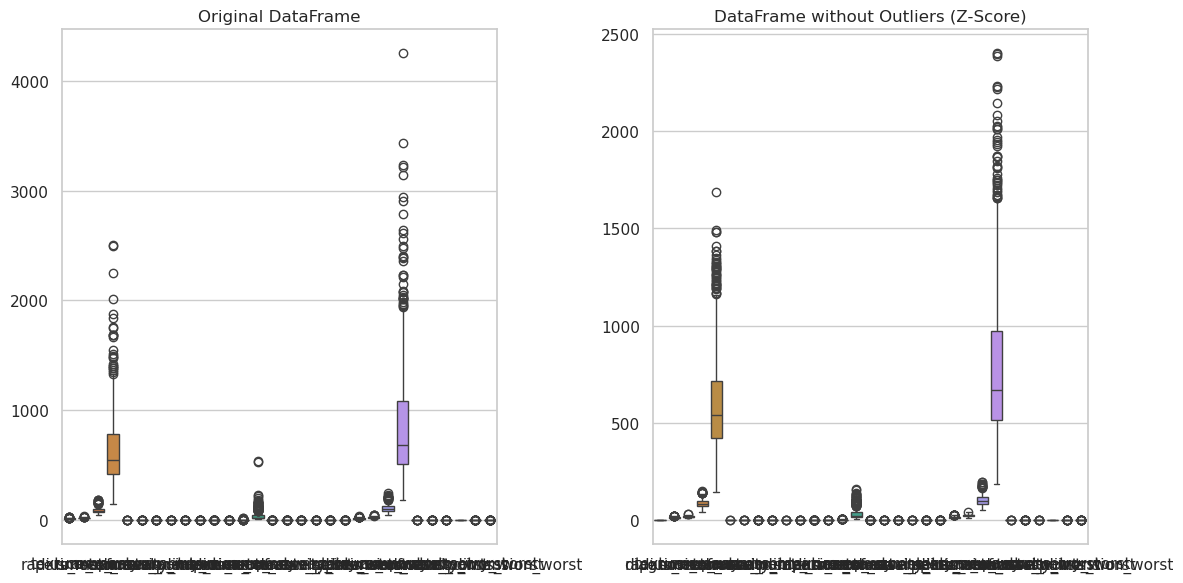

In [108]:
#Set the style for seaborn
sns.set(style="whitegrid")

# Box plot for original DataFrame
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(data=numeric_df)
plt.title("Original DataFrame")

# Box plot for DataFrame without outliers
plt.subplot(1, 2, 2)
sns.boxplot(data=df_no_outliers_z)  # Change to df_no_outliers_iqr for IQR
plt.title("DataFrame without Outliers (Z-Score)")

plt.tight_layout()
plt.show()

In [109]:
# Now, Convet the categorical column satisfaction into numeric
df_no_outliers_z.loc[:,'diagnosis'] = OneHotEncoder(drop = 'first').fit_transform(df_no_outliers_z[['diagnosis']]).toarray()

In [145]:
df_no_outliers_z

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1.00,20.57,17.77,132.90,1326.00,0.08,0.08,0.09,0.07,0.18,0.06,0.54,0.73,3.40,74.08,0.01,0.01,0.02,0.01,0.01,0.00,24.99,23.41,158.80,1956.00,0.12,0.19,0.24,0.19,0.28,0.09
1,1.00,19.69,21.25,130.00,1203.00,0.11,0.16,0.20,0.13,0.21,0.06,0.75,0.79,4.58,94.03,0.01,0.04,0.04,0.02,0.02,0.00,23.57,25.53,152.50,1709.00,0.14,0.42,0.45,0.24,0.36,0.09
2,1.00,20.29,14.34,135.10,1297.00,0.10,0.13,0.20,0.10,0.18,0.06,0.76,0.78,5.44,94.44,0.01,0.02,0.06,0.02,0.02,0.01,22.54,16.67,152.20,1575.00,0.14,0.20,0.40,0.16,0.24,0.08
3,1.00,12.45,15.70,82.57,477.10,0.13,0.17,0.16,0.08,0.21,0.08,0.33,0.89,2.22,27.19,0.01,0.03,0.04,0.01,0.02,0.01,15.47,23.75,103.40,741.60,0.18,0.52,0.54,0.17,0.40,0.12
4,1.00,18.25,19.98,119.60,1040.00,0.09,0.11,0.11,0.07,0.18,0.06,0.45,0.77,3.18,53.91,0.00,0.01,0.02,0.01,0.01,0.00,22.88,27.66,153.20,1606.00,0.14,0.26,0.38,0.19,0.31,0.08
5,1.00,13.71,20.83,90.20,577.90,0.12,0.16,0.09,0.06,0.22,0.07,0.58,1.38,3.86,50.96,0.01,0.03,0.02,0.01,0.01,0.01,17.06,28.14,110.60,897.00,0.17,0.37,0.27,0.16,0.32,0.12
6,1.00,13.00,21.82,87.50,519.80,0.13,0.19,0.19,0.09,0.23,0.07,0.31,1.00,2.41,24.32,0.01,0.04,0.04,0.01,0.02,0.00,15.49,30.73,106.20,739.30,0.17,0.54,0.54,0.21,0.44,0.11
7,1.00,16.02,23.24,102.70,797.80,0.08,0.07,0.03,0.03,0.15,0.06,0.38,1.19,2.47,40.51,0.00,0.01,0.01,0.01,0.01,0.00,19.19,33.88,123.80,1150.00,0.12,0.16,0.15,0.10,0.29,0.08
8,1.00,15.78,17.89,103.60,781.00,0.10,0.13,0.10,0.07,0.18,0.06,0.51,0.98,3.56,54.16,0.01,0.04,0.03,0.01,0.02,0.00,20.42,27.28,136.50,1299.00,0.14,0.56,0.40,0.18,0.38,0.10
9,1.00,15.85,23.95,103.70,782.70,0.08,0.10,0.10,0.05,0.18,0.05,0.40,1.08,2.90,36.58,0.01,0.03,0.05,0.02,0.03,0.00,16.84,27.66,112.00,876.50,0.11,0.19,0.23,0.11,0.28,0.06


In [149]:
## Dividing the dataset into dependent and independent features

X = df_no_outliers_z.iloc[:,1:] ## Independent Features
y = df_no_outliers_z.iloc[:,0] ## Dependent Features



X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

In [147]:
# Now , Normalize the data Or Scale the dataset 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)

In [150]:
classifier = LogisticRegression()
classifier.fit(X_train, y_train)

ValueError: Unknown label type: unknown. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

In [ ]:
## Prediction
y_pred = classifier.predict(X_test)